# Step 5：来源4首周活跃深度分层

## 业务问题

来源4首次活动覆盖率约为90.60%，但首周持续使用深度偏弱。本 Notebook 进一步回答：在2015年10月7日至31日注册的来源4用户内部，首7天活跃天数与D30留存是否存在稳定梯度？

本分析只使用已有用户级底表，不重新扫描原始行为日志。结果是相关性证据，不是因果识别。


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
BASE_PATH = PROJECT_ROOT / "data/processed/new_user_anomaly_base.csv"
OUTPUT_CSV = PROJECT_ROOT / "data/processed/source4_engagement_stratification.csv"
OUTPUT_PNG = PROJECT_ROOT / "outputs/source4_engagement_stratification.png"


## 分析人群与分层

- 注册日期：2015-10-07至2015-10-31
- 注册来源：`registered_via = 4`
- 分层：首7天活跃0–1天、2天、至少3天
- 指标：用户数、用户占比、D7/D30、首7天平均播放秒数、首7天平均完整播放次数


In [2]:
usecols = ["msno", "registration_date", "registered_via", "first_7d_active_days",
           "first_7d_total_secs", "first_7d_num_100", "d7_retained", "d30_retained"]
df = pd.read_csv(BASE_PATH, usecols=usecols, parse_dates=["registration_date"])
source4 = df[df["registration_date"].between("2015-10-07", "2015-10-31") & df["registered_via"].eq(4)].copy()
source4["engagement_tier"] = pd.cut(source4["first_7d_active_days"], [-1, 1, 2, np.inf], labels=["0-1天", "2天", ">=3天"])
print(f"来源4分析用户数：{len(source4):,}")
source4["first_7d_active_days"].value_counts().sort_index()


来源4分析用户数：172,259


first_7d_active_days
0    21992
1    66699
2    30471
3    20728
4    17515
5     9111
6     3152
7     2591
Name: count, dtype: int64

In [3]:
result = (source4.groupby("engagement_tier", observed=False)
          .agg(users=("msno", "nunique"),
               d7_retention_rate=("d7_retained", "mean"),
               d30_retention_rate=("d30_retained", "mean"),
               avg_first_7d_total_secs=("first_7d_total_secs", "mean"),
               avg_first_7d_num_100=("first_7d_num_100", "mean"))
          .reset_index())
result.insert(2, "user_share", result["users"] / result["users"].sum())
result.to_csv(OUTPUT_CSV, index=False, encoding="utf-8-sig")
result.style.format({"user_share":"{:.2%}", "d7_retention_rate":"{:.2%}", "d30_retention_rate":"{:.2%}", "avg_first_7d_total_secs":"{:,.2f}", "avg_first_7d_num_100":"{:.2f}"})


,engagement_tier,users,user_share,d7_retention_rate,d30_retention_rate,avg_first_7d_total_secs,avg_first_7d_num_100
0,0-1天,88691,51.49%,1.50%,0.45%,"1,200.43",3.49
1,2天,30471,17.69%,3.43%,0.89%,"5,507.09",17.03
2,>=3天,53097,30.82%,12.06%,6.43%,"21,784.10",72.53


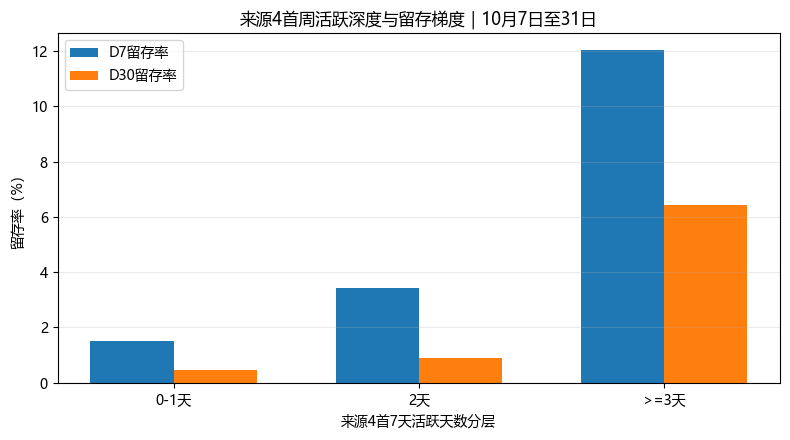

In [4]:
from matplotlib import font_manager
font_manager.fontManager.addfont(r"C:\Windows\Fonts\msyh.ttc")
plt.rcParams["font.family"] = "Microsoft YaHei"
plt.rcParams["axes.unicode_minus"] = False
x = np.arange(len(result)); width = 0.34
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(x-width/2, result["d7_retention_rate"]*100, width, label="D7留存率")
ax.bar(x+width/2, result["d30_retention_rate"]*100, width, label="D30留存率")
ax.set_xticks(x, result["engagement_tier"].astype(str)); ax.set_xlabel("来源4首7天活跃天数分层")
ax.set_ylabel("留存率（%）"); ax.set_title("来源4首周活跃深度与留存梯度｜10月7日至31日")
ax.legend(); ax.grid(axis="y", alpha=.25); fig.tight_layout(); fig.savefig(OUTPUT_PNG, dpi=160)
plt.show()


## 真实结果与业务解释

| 首7天活跃分层 | 用户数 | 用户占比 | D7 | D30 | 平均播放秒数 | 平均完整播放数 |
|---|---:|---:|---:|---:|---:|---:|
| 0–1天 | 88,691 | 51.49% | 1.50% | 0.45% | 1,200.43 | 3.49 |
| 2天 | 30,471 | 17.69% | 3.43% | 0.89% | 5,507.09 | 17.03 |
| 至少3天 | 53,097 | 30.82% | 12.06% | 6.43% | 21,784.10 | 72.53 |

D7、D30、播放时长和完整播放次数均随首周活跃层级提升而上升，呈明显单调梯度。来源4的问题不是“无法完成首次活动”，而更集中在首次活动后的D2–D7持续使用不足。因此后续运营和实验可以优先推动首周重复使用。

边界：该分层是观察性相关分析，不能证明增加活跃天数会因果性提高D30；具体方案仍需随机实验验证。
